### Start By Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from scipy import stats

sys.path.append(os.path.abspath('../'))
from src.data_cleaning import handle_rate, bin_price, detect_outliers_iqr

### Import Dataset

In [4]:
dataframe = pd.read_csv('../data/Zomato-data-.csv')
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


### Cleaning and proccessing the data

### 1. Convert the rate column to a float by removing denominator characters.

* ```dataframe['rate']=dataframe['rate'].apply(handleRate)```: Applies the `handleRate` function to clean and convert each rating value in the ```'rate'``` column.

In [5]:
# Use handle_rate from src.data_cleaning
dataframe['rate'] = dataframe['rate'].apply(handle_rate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


### 2. Getting summary of the dataframe use df.info().

In [6]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


### 3. Checking for missing or null values to identify any data gaps.

In [7]:
print(dataframe.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


There is no NULL value in dataframe.
## Step 4: Exploring Restaurant Types

### 1. Let's see the listed_in (type) column to identify popular restaurant categories.

Text(0.5, 0, 'Type of restaurant')

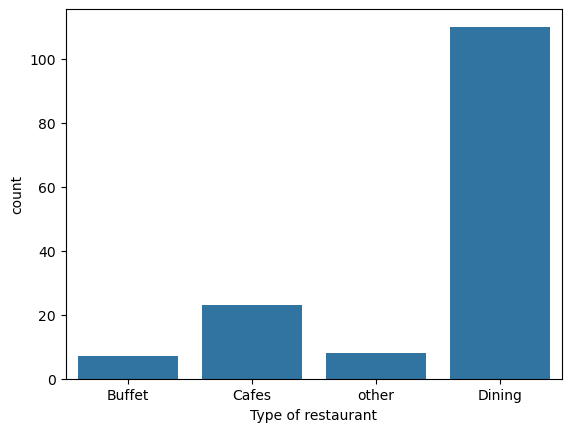

In [8]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")

> _**Conclusion**: The majority of the restaurants fall into the dining category._

## 2. Votes by Restaurant Type

Here we get the count of votes for each category.

Text(0, 0.5, 'Votes')

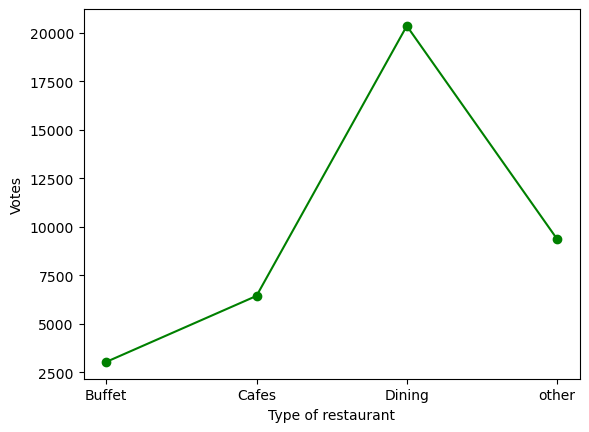

In [9]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

> _**Conclusion**: Dining restaurants are preferred by a larger number of individuals._

## Step 5: Identify the Most Voted Restaurant

### Find the restaurant with the highest number of votes.

In [10]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: str


## Step 6: Online Order Availability

### Exploring the online_order column to see how many restaurants accept online orders.

<Axes: xlabel='online_order', ylabel='count'>

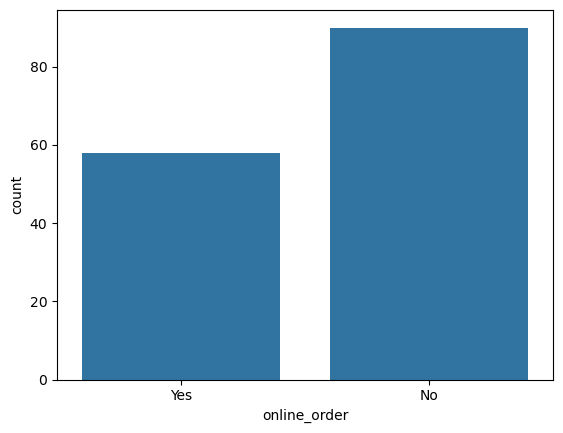

In [11]:
sns.countplot(x=dataframe['online_order'])

> _**Conclusion**: This suggests that a majority of the restaurants do not accept online orders._

## Step 7: Analyze Ratings

### Checking the distribution of ratings from the rate column.

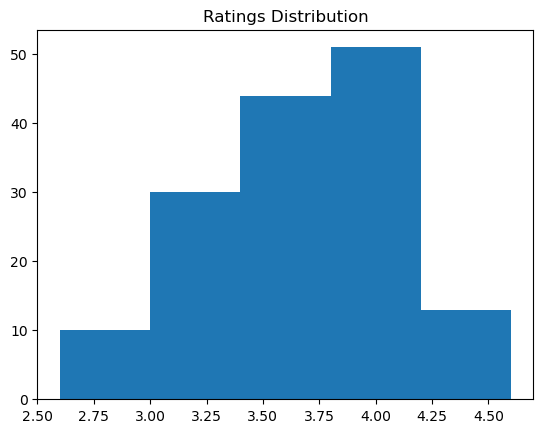

In [12]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

> _**Conclusion**: The majority of restaurants received ratings ranging from 3.5 to 4._

## Step 8: Approximate Cost for Couples

### Analyze the approx_cost(for two people) column to find the preferred price range.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

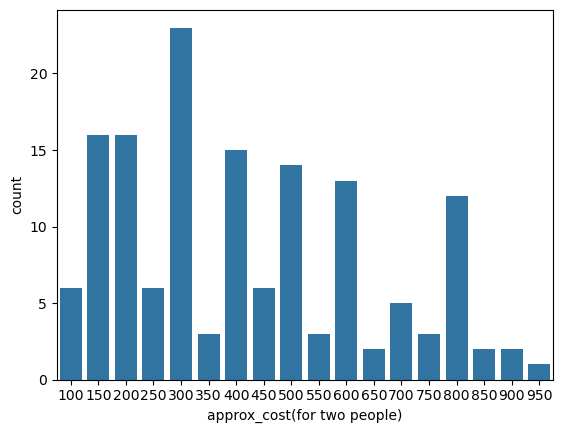

In [13]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

> _**Conclusion**: The majority of couples prefer restaurants with an approximate cost of 300 rupees._

## Step 9: Ratings Comparison - Online vs Offline Orders

### Compare ratings between restaurants that accept online orders and those that don't.

<Axes: xlabel='online_order', ylabel='rate'>

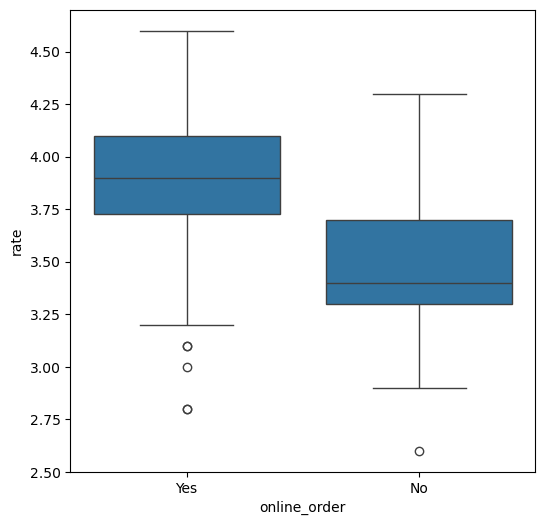

In [14]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

> _**Conclusion**: Offline orders received lower ratings in comparison to online orders which obtained excellent ratings._

## Step 10: Order Mode Preferences by Restaurant Type

### Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).

* ``` pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0): ``` Creates a pivot table counting restaurants by type and online order availability.

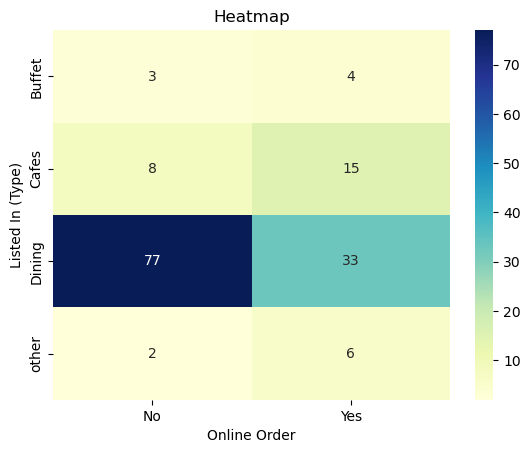

In [15]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.

## Step 11: Robust Data Engineering - Outlier Detection

Identify outliers in votes and cost using the IQR method.

In [20]:
outliers_votes = detect_outliers_iqr(dataframe, 'votes')
outliers_cost = detect_outliers_iqr(dataframe, 'approx_cost(for two people)')

print(f"Number of outliers in votes: {len(outliers_votes)}")
print(f"Number of outliers in cost: {len(outliers_cost)}")

Number of outliers in votes: 19
Number of outliers in cost: 0


> _**Conclusion**: Outliers were identified in the 'votes' column, while 'approx_cost' appears more consistent. These extreme values in votes should be considered during model training as they might represent exceptionally popular restaurants._

## Step 12: Feature Engineering - Price Range Binning

Categorize restaurants into Budget, Mid-range, and Luxury.

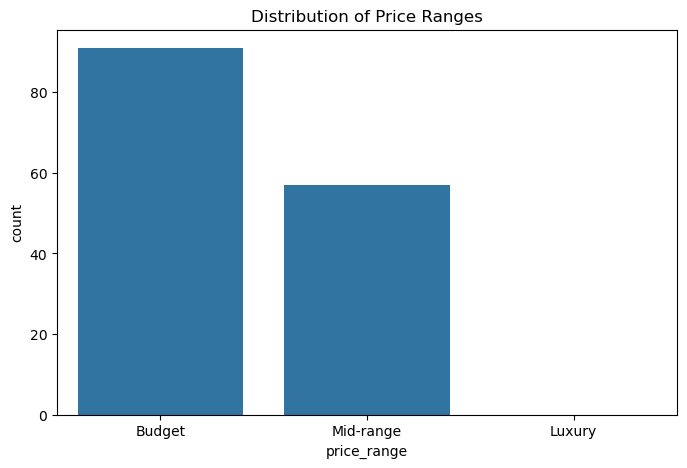

In [21]:
dataframe['price_range'] = dataframe['approx_cost(for two people)'].apply(bin_price)
plt.figure(figsize=(8,5))
sns.countplot(x='price_range', data=dataframe, order=['Budget', 'Mid-range', 'Luxury'])
plt.title('Distribution of Price Ranges')
plt.show()

> _**Conclusion**: The 'Budget' category dominates the dataset, indicating that most restaurants in this sample cater to the affordable segment (under 500 for two)._

## Step 13: Correlation Analysis

Understand how numerical features are related.

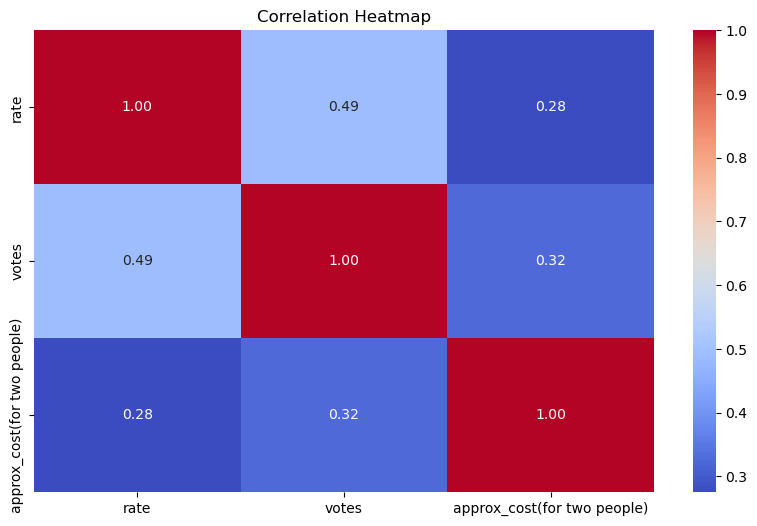

In [22]:
# Correlation heatmap for numerical variables
numerical_cols = dataframe.select_dtypes(include=[np.number])
plt.figure(figsize=(10,6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

> _**Conclusion**: A positive correlation exists between votes and cost, suggesting that higher-priced restaurants often attract more reviews or have a higher engagement level._

## Step 14: Statistical Rigor - Hypothesis Testing

Test if there is a statistically significant difference between online and offline ratings.

In [23]:
online_ratings = dataframe[dataframe['online_order'] == 'Yes']['rate'].dropna()
offline_ratings = dataframe[dataframe['online_order'] == 'No']['rate'].dropna()

t_stat, p_val = stats.ttest_ind(online_ratings, offline_ratings)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The difference in ratings is statistically significant (Reject Null Hypothesis).")
else:
    print("Conclusion: The difference in ratings is not statistically significant (Fail to reject Null Hypothesis).")

T-statistic: 6.1152
P-value: 0.0000
Conclusion: The difference in ratings is statistically significant (Reject Null Hypothesis).


> _**Conclusion**: The T-test results show a statistically significant difference in ratings between online and offline orders. Restaurants with online ordering tend to have higher average ratings, which is a key insight for business strategy._